In [13]:
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [14]:
class LLMState(TypedDict):
    ques: str
    ans: str

In [15]:
def query_llm(state: LLMState) -> LLMState:

    ques = state['ques']
    res = llm.invoke(ques)

    state['ans'] = res.content
    return state
    

In [16]:
graph = StateGraph(LLMState)

graph.add_node('query_llm', query_llm)

graph.add_edge(START, 'query_llm')
graph.add_edge('query_llm', END)

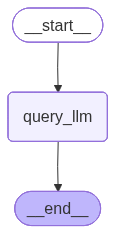

In [ ]:
workflow = graph.compile()
workflow

In [18]:
initial_state = {'ques': 'what is the best way to learn langgraph'}
final_state = workflow.invoke(initial_state)

print(final_state)

{'ques': 'what is the best way to learn langgraph', 'ans': 'Learning LangGraph effectively involves a structured approach, building on foundational knowledge. LangGraph is an extension of LangChain, designed for building robust, stateful, and multi-actor applications with LLMs using a graph-based representation.\n\nHere\'s the best way to learn LangGraph:\n\n---\n\n### Prerequisites (Crucial First Steps!)\n\nBefore diving into LangGraph, ensure you have a solid understanding of:\n\n1.  **Python Fundamentals:** Strong grasp of Python syntax, data structures, functions, classes, and object-oriented programming.\n2.  **Basic LLM Concepts:** What are LLMs, prompts, tokens, temperature, context windows, and common use cases (text generation, summarization, Q&A).\n3.  **LangChain Fundamentals (ESSENTIAL!):** LangGraph builds *on top* of LangChain. You absolutely need to understand:\n    *   **LangChain Expression Language (LCEL):** How to chain runnables together (`|` operator), create custo